# Анализ прямой задачи

В формулы подставляется и варьруется величина волнового числа $k = w\sqrt{\mu_0\mu\epsilon_0\epsilon}$ и толщины слоя $h$.

Известно, что $$c = \frac{1}{\sqrt{\mu_0\epsilon_0}}$$, тогда получаем, что $$k = \frac{w}{c}\sqrt{\mu\epsilon}$$, где $$w - \text{круговая частота}$$ $$c - \text{скорость света}$$ $$\mu,\epsilon - \text{показатели среды}$$

Тогда $k_0 = \frac{w}{c} = \frac{2\pi}{\lambda_0}$ - волновое чсило вакуума, а $n = \sqrt{\mu\epsilon}$ - показатель преломления.

Для исследования некорректности обратной задачи зафиксируем длину волны $\lambda_0$ в коде и будем вычислять остальные величины как: $$k_0 = \frac{2\pi}{\lambda_0}$$ $$\tilde{h} = k_0h$$ $$\tilde{k}=\frac{k}{k_0} = n_i$$

То есть $k = n_ik_0$, а $\tilde{h}=k_0h$ - безразмерные величины

## Import

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from physics import *

In [68]:
theta0 = np.deg2rad(30)

lambda0 = 2 * np.pi # Длина волны в метрах
k0 = 2 * np.pi / lambda0

n1 = 1.0 # воздух
n2 = 1.0 # подложка

h = 0.5 # толщина слоя в метрах
theta0 = np.deg2rad(30) # Угол в радианах

In [69]:
n_vals = np.linspace(0.0, 12.0, 10000) # Показатели преломления материала

r_vals = [r_total(np.array([n1, n, n2]) * k0, h, theta0) for n in n_vals] # Посчитанные значения коэфициентов отражения

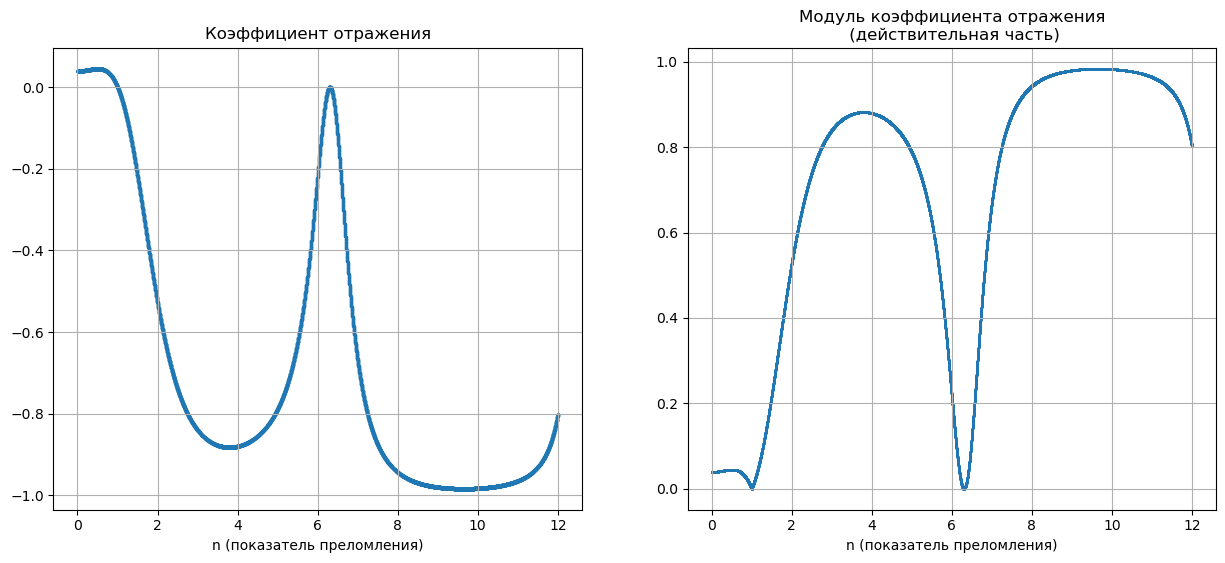

In [70]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(15, 6))

ax1.scatter(n_vals, np.real(r_vals), s=2)
ax1.set_title('Коэффициент отражения')
ax1.set_xlabel('n (показатель преломления)')
ax1.grid()

ax2.scatter(n_vals, np.abs(np.real(r_vals)), s=1)
ax2.set_title('Модуль коэффициента отражения\n (действительная часть)')
ax2.set_xlabel('n (показатель преломления)')
ax2.grid()

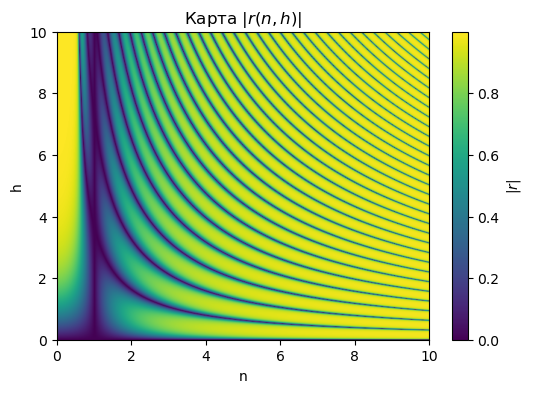

In [ ]:
h_vals = np.linspace(0, 10, 500)
n_vals = np.linspace(0, 10, 500)

R = np.zeros((len(h_vals), len(n_vals)), dtype=complex)

for i, h in enumerate(h_vals):
    R[i, :] = [
        r_total(np.array([n1, n, n2]) * k0, h, theta0)
        for n in n_vals
    ]

plt.figure(figsize=(6, 4))
plt.imshow(
    np.abs(R),
    origin="lower",
    extent=[n_vals.min(), n_vals.max(), h_vals.min(), h_vals.max()],
    aspect="auto"
)
plt.colorbar(label=r"$|r|$")
plt.xlabel("n")
plt.ylabel("h")
plt.title(r"Карта $|r(n,h)|$")
plt.show()

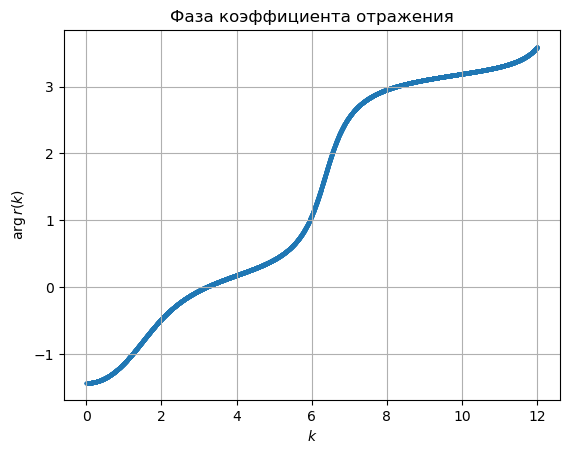

In [71]:
plt.figure()
plt.scatter(n_vals, np.unwrap(np.angle(r_vals), period=np.pi), s=3)
plt.xlabel(r"$k$")
plt.ylabel(r"$\arg r(k)$")
plt.title("Фаза коэффициента отражения")
plt.grid()
plt.show()

In [73]:
print("Максимум |r| =", np.max(np.abs(r_vals)))

Максимум |r| = 0.9839617700984582


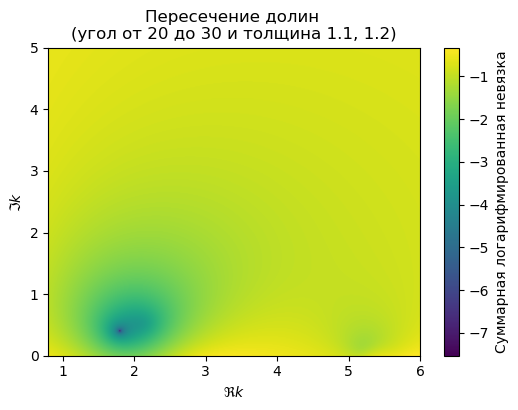

In [ ]:
total_misfit = 0
count = 0

for si in range(20, 30, 2):
    for hi in range(1, 3):
        Ri = r_total(K, k0, k2, np.deg2rad(si), 1+hi*0.1)
        ri_meas = r_total(k_star, k0, k2, np.deg2rad(si), 1+hi*0.1)
        misfit_i = np.abs(Ri - ri_meas)**2

        total_misfit += misfit_i
        count += 1

total_misfit /= count

plt.figure(figsize=(6, 4))
plt.imshow(
    np.log10(total_misfit),
    origin="lower",
    extent=[k_real.min(), k_real.max(), k_imag.min(), k_imag.max()],
    aspect="auto"
)
plt.colorbar(label="Суммарная логарифмированная невязка")
plt.xlabel(r"$\Re k$")
plt.ylabel(r"$\Im k$")
plt.title("Пересечение долин \n(угол от 20 до 30 и толщина 1.1, 1.2)")
plt.show()


In [ ]:
idx = np.unravel_index(np.argmin(total_misfit), total_misfit.shape)
print(K[idx])

(1.7993993993993995+0.4013377926421404j)


### Вывод
 - При наличии набора углов и толщин функционал невязки имеет единственную устойчивую область минимума в пространстве комплексного волнового числа.
  - Использование квадратичного функционала невязки приводит к расширению области визуального минимума вследствие слабой чувствительности нормы второго порядка вблизи нуля. Однако логарифмическое масштабирование выявляет локальную структуру минимума, которая остаётся устойчиво локализованной в окрестности истинного параметра.